# 01 — Đánh giá MODEL A: GIÁ CƠ BẢN

Nạp lại dự đoán đã lưu từ `train/01_train_gia_co_ban.ipynb` (`pred_gia_co_ban.parquet`) — **không
train lại**, chạy rất nhanh.

Đây là model **lõi của Hybrid** — độ chính xác của nó quyết định phần lớn độ chính xác giá cuối.

In [1]:
import warnings
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
warnings.filterwarnings("ignore")
%matplotlib inline
plt.rcParams.update({"figure.facecolor":"white","axes.spines.top":False,"axes.spines.right":False,
                     "axes.grid":True,"grid.color":"#ECECEC","font.size":10})
pd.set_option("display.width", 220)
BLUE, ORANGE, GREEN = "#0072B2", "#E69F00", "#009E73"

def metrics(y, p):
    y, p = np.asarray(y), np.asarray(p)
    return dict(MAE=mean_absolute_error(y,p), RMSE=mean_squared_error(y,p)**.5,
                R2=r2_score(y,p), MAPE=np.mean(np.abs((y-p)/y))*100)

PRED = Path("pred_gia_co_ban.parquet")
assert PRED.exists(), "Chua co file du doan -> chay train/01_train_gia_co_ban.ipynb truoc!"
df = pd.read_parquet(PRED)
ALGOS = sorted(df.algo.unique())
thangs = sorted(df.evaluation_month.unique())
print(f"Nap {len(df):,} dong du doan | thuat toan: {ALGOS} | thang: {thangs}")

Nap 2,593,080 dong du doan | thuat toan: ['HistGB', 'LightGBM', 'XGBoost'] | thang: ['2026-01', '2026-02', '2026-03']


## 1. Bảng chỉ số — tổng gộp & từng test-set nhỏ theo tháng

In [2]:
rows = []
for algo in ALGOS:
    d = df[df.algo==algo]
    rows.append({"Thuat toan": algo, "Test-set": "TAT CA", "n": len(d), **metrics(d.base_price, d.base_pred)})
    for th in thangs:
        dt = d[d.evaluation_month==th]
        rows.append({"Thuat toan": algo, "Test-set": th, "n": len(dt), **metrics(dt.base_price, dt.base_pred)})
bang = pd.DataFrame(rows).round(2)
print("TONG GOP:"); display(bang[bang["Test-set"]=="TAT CA"].sort_values("MAE"))
print("\nTUNG TEST-SET NHO THEO THANG:"); display(bang[bang["Test-set"]!="TAT CA"])
print("\n(Tham chieu tuan 2: HistGB MAE ~15.032 VND | R2 ~0,656 | MAPE ~14,6%)")

TONG GOP:


,Thuat toan,Test-set,n,MAE,RMSE,R2,MAPE
0,HistGB,TAT CA,864360,15031.56,20076.67,0.66,14.58
4,LightGBM,TAT CA,864360,15037.54,20079.35,0.66,14.59
8,XGBoost,TAT CA,864360,15045.36,20097.12,0.66,14.60



TUNG TEST-SET NHO THEO THANG:


,Thuat toan,Test-set,n,MAE,RMSE,R2,MAPE
1,HistGB,2026-01,315360,15066.55,20166.61,0.66,14.60
2,HistGB,2026-02,234632,14968.72,19930.88,0.66,14.56
3,HistGB,2026-03,314368,15043.35,20094.64,0.65,14.59
5,LightGBM,2026-01,315360,15075.88,20170.46,0.66,14.61
6,LightGBM,2026-02,234632,14972.30,19926.85,0.66,14.57
7,LightGBM,2026-03,314368,15047.77,20101.12,0.65,14.59
9,XGBoost,2026-01,315360,15075.61,20176.50,0.66,14.61
10,XGBoost,2026-02,234632,14992.38,19962.38,0.66,14.58
11,XGBoost,2026-03,314368,15054.56,20117.55,0.65,14.60



(Tham chieu tuan 2: HistGB MAE ~15.032 VND | R2 ~0,656 | MAPE ~14,6%)


## 2. Biểu đồ — cả 3 thuật toán

Mỗi hàng 1 thuật toán: (a) dự đoán vs thực tế · (b) phân bố sai số.

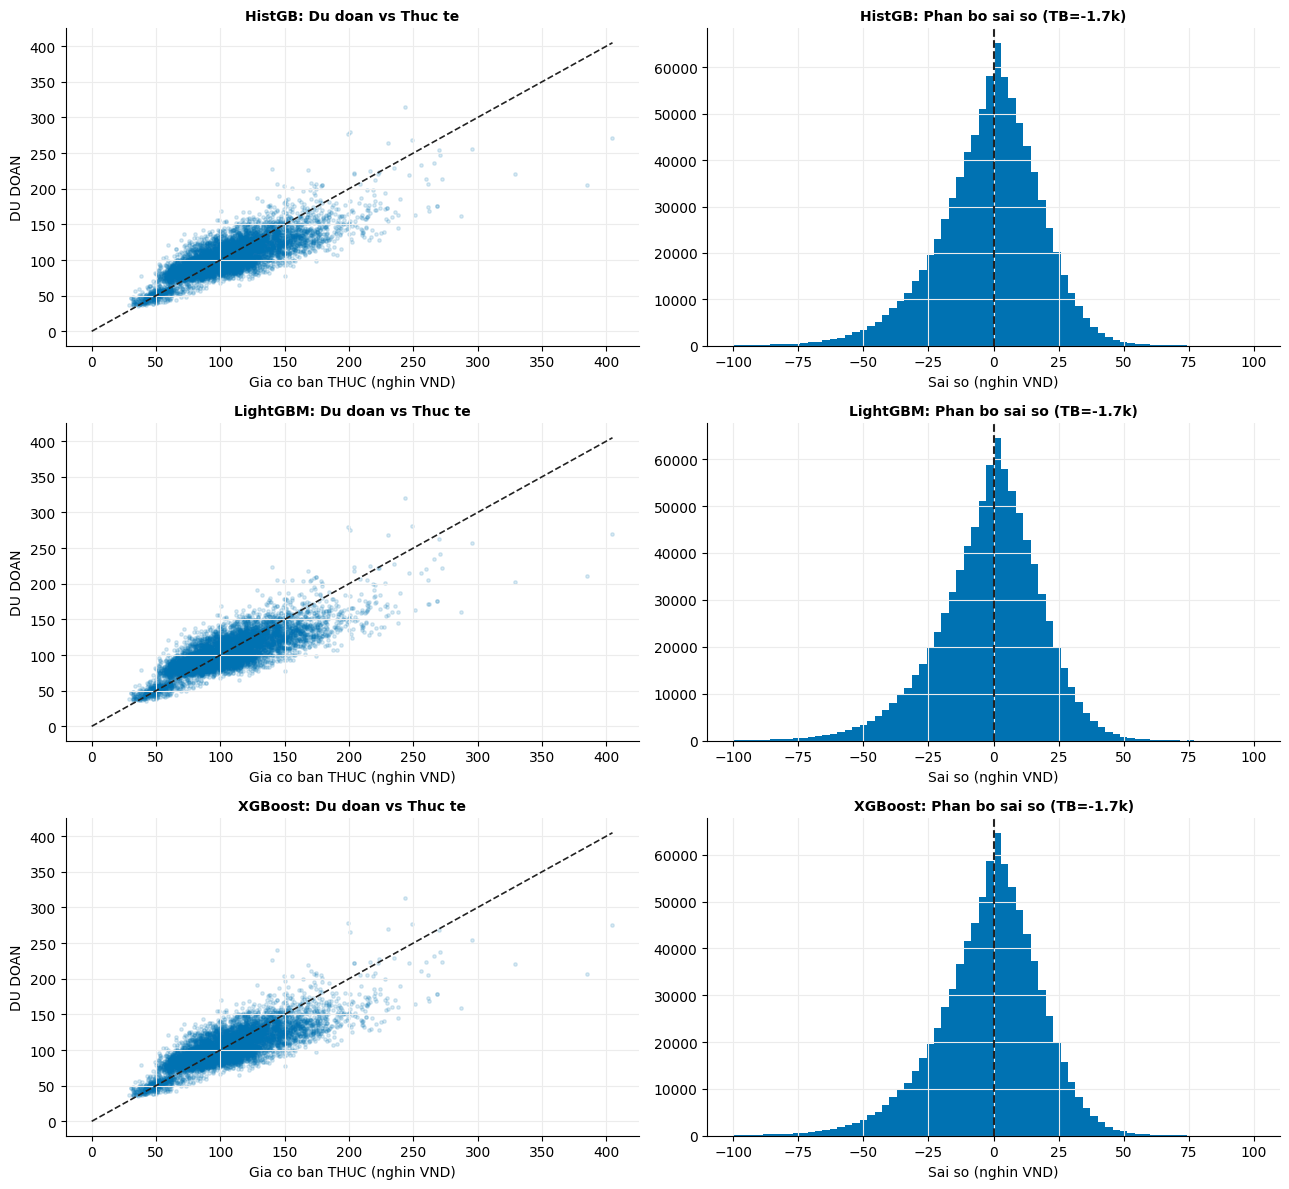

In [3]:
fig, axes = plt.subplots(len(ALGOS), 2, figsize=(13, 4*len(ALGOS)))
if len(ALGOS) == 1: axes = axes.reshape(1, -1)
for i, algo in enumerate(ALGOS):
    d = df[df.algo==algo]
    s = d.sample(min(8000, len(d)), random_state=0)
    axes[i,0].scatter(s.base_price/1000, s.base_pred/1000, s=6, alpha=.15, color=BLUE)
    lim = [0, s.base_price.max()/1000]
    axes[i,0].plot(lim, lim, "--", color="#222", lw=1.2)
    axes[i,0].set_xlabel("Gia co ban THUC (nghin VND)"); axes[i,0].set_ylabel("DU DOAN")
    axes[i,0].set_title(f"{algo}: Du doan vs Thuc te", fontweight="bold", fontsize=10)

    err = (d.base_pred - d.base_price)/1000
    axes[i,1].hist(err, bins=70, range=(-100,100), color=BLUE)
    axes[i,1].axvline(0, color="#222", ls="--")
    axes[i,1].set_xlabel("Sai so (nghin VND)")
    axes[i,1].set_title(f"{algo}: Phan bo sai so (TB={err.mean():+.1f}k)", fontweight="bold", fontsize=10)
plt.tight_layout(); plt.show()

## 3. So sánh MAE giữa 3 thuật toán

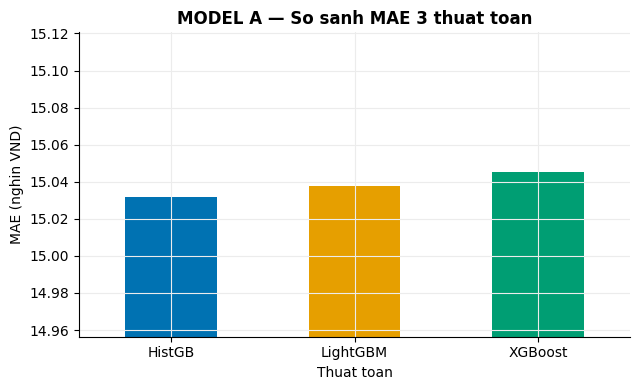

Chenh lech giua thuat toan tot nhat va kem nhat: 14 VND (0.09%)
-> Neu < 0,5%: 3 thuat toan tuong duong, chon HistGB (khong can thu vien ngoai sklearn).


In [4]:
bt = bang[bang["Test-set"]=="TAT CA"].set_index("Thuat toan")["MAE"]/1000
fig, ax = plt.subplots(figsize=(6.5,4))
bt.plot(kind="bar", ax=ax, color=[BLUE, ORANGE, GREEN][:len(bt)])
ax.set_ylabel("MAE (nghin VND)"); ax.set_title("MODEL A — So sanh MAE 3 thuat toan", fontweight="bold")
ax.tick_params(axis="x", rotation=0)
lo, hi = bt.min(), bt.max()
ax.set_ylim(lo*0.995, hi*1.005)   # zoom de thay ro chenh lech nho
plt.tight_layout(); plt.show()
print(f"Chenh lech giua thuat toan tot nhat va kem nhat: {(hi-lo)*1000:,.0f} VND ({(hi/lo-1)*100:.2f}%)")
print("-> Neu < 0,5%: 3 thuat toan tuong duong, chon HistGB (khong can thu vien ngoai sklearn).")

## 4. Sai số theo mức giá — model đoán tốt ở khoảng nào?

Chia giá cơ bản thực tế thành 10 nhóm, xem MAPE từng nhóm. Giúp biết model yếu ở chuyến rẻ hay đắt.

Sai so theo nhom gia (HistGB):


,n,gia_TB_k,MAE_k,MAPE,bias_k
nhom_gia,,,,,
"(27118.644, 64367.816]",86452.0,53.24,10.48,19.22,8.28
"(64367.816, 76377.953]",86452.0,70.99,14.60,20.71,13.05
"(76377.953, 84615.391]",86580.0,80.59,11.10,13.80,9.03
"(84615.391, 91935.484]",86320.0,88.28,10.28,11.65,5.44
"(91935.484, 99285.719]",86464.0,95.71,11.09,11.58,2.24
"(99285.719, 107377.047]",86408.0,103.40,12.66,12.24,-0.55
"(107377.047, 116666.672]",86640.0,111.98,13.74,12.27,-3.55
"(116666.672, 128751.634]",86172.0,122.42,15.16,12.38,-7.44
"(128751.634, 147154.469]",86468.0,137.10,18.56,13.50,-13.78


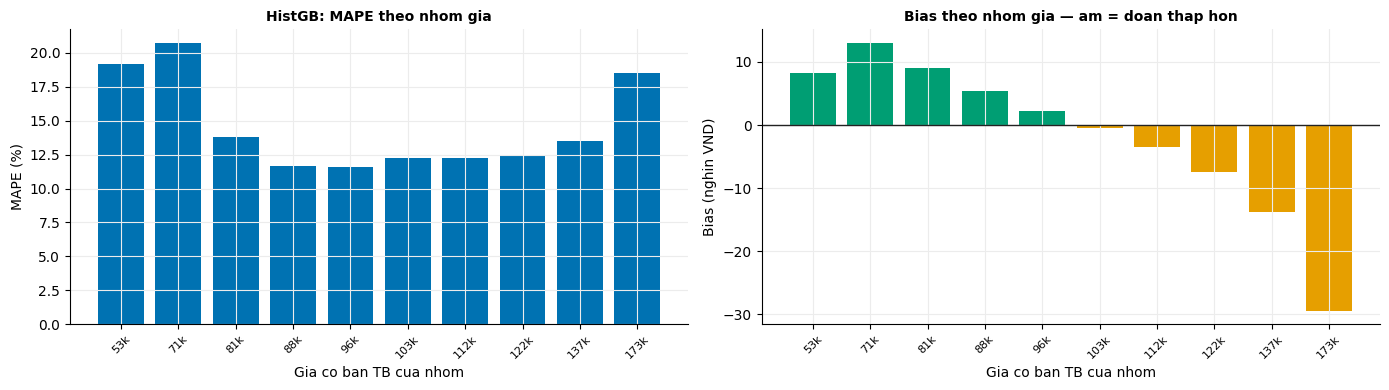

-> Bias thuong am o nhom gia cao, duong o nhom gia thap = hien tuong shrinkage cua regression.


In [5]:
best_algo = bang[bang["Test-set"]=="TAT CA"].sort_values("MAE").iloc[0]["Thuat toan"]
d = df[df.algo==best_algo].copy()
d["nhom_gia"] = pd.qcut(d.base_price, 10, duplicates="drop")
g = d.groupby("nhom_gia", observed=True).apply(
    lambda x: pd.Series({
        "n": len(x),
        "gia_TB_k": x.base_price.mean()/1000,
        "MAE_k": (x.base_pred - x.base_price).abs().mean()/1000,
        "MAPE": ((x.base_pred - x.base_price).abs()/x.base_price).mean()*100,
        "bias_k": (x.base_pred - x.base_price).mean()/1000,
    })).round(2)
print(f"Sai so theo nhom gia ({best_algo}):"); display(g)

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ax[0].bar(range(len(g)), g.MAPE, color=BLUE)
ax[0].set_xticks(range(len(g))); ax[0].set_xticklabels([f"{v:.0f}k" for v in g.gia_TB_k], rotation=45, fontsize=8)
ax[0].set_xlabel("Gia co ban TB cua nhom"); ax[0].set_ylabel("MAPE (%)")
ax[0].set_title(f"{best_algo}: MAPE theo nhom gia", fontweight="bold", fontsize=10)

ax[1].bar(range(len(g)), g.bias_k, color=[ORANGE if v<0 else GREEN for v in g.bias_k])
ax[1].axhline(0, color="#222", lw=1)
ax[1].set_xticks(range(len(g))); ax[1].set_xticklabels([f"{v:.0f}k" for v in g.gia_TB_k], rotation=45, fontsize=8)
ax[1].set_xlabel("Gia co ban TB cua nhom"); ax[1].set_ylabel("Bias (nghin VND)")
ax[1].set_title("Bias theo nhom gia — am = doan thap hon", fontweight="bold", fontsize=10)
plt.tight_layout(); plt.show()
print("-> Bias thuong am o nhom gia cao, duong o nhom gia thap = hien tuong shrinkage cua regression.")

## Kết luận

- **Bước 1** cho MAE/R²/MAPE tổng thể và độ ổn định qua 3 tháng.
- **Bước 3**: nếu 3 thuật toán chênh < 0,5% → chọn HistGB (đơn giản nhất, không cần thư viện ngoài).
- **Bước 4** cho biết model yếu ở khoảng giá nào; bias âm ở nhóm giá cao + dương ở nhóm giá thấp là
  *shrinkage* — đặc tính tự nhiên của regression, đã thử smearing correction nhưng không cải thiện.

> **Tham chiếu sàn nhiễu:** MAE ~15.000 VND / MAPE ~14,6% đã được xác nhận là **giới hạn của dữ liệu**
> qua 8 hướng thử độc lập (xem `docs/report_tuan2.md` mục 5). Không nên kỳ vọng cải thiện thêm bằng
> cách đổi thuật toán/feature/tham số.